<div style="
    background: linear-gradient(135deg, #2b1708, #4a2c18, #1f1007);
    padding: 40px;
    border-radius: 25px;
    border: 2px solid #d6b77a;
    box-shadow: 
        0 0 25px rgba(214,183,122,0.35),
        inset 0 0 20px rgba(255,255,255,0.05);
    text-align: center;
">

<h1 style="
    font-family: 'Georgia', serif;
    font-size: 40px;
    font-weight: 900;
    color: #f5deb3;
    text-shadow:
        0 0 8px #d6b77a,
        0 0 15px #c19a6b,
        2px 3px 5px rgba(0,0,0,0.8);
    letter-spacing: 2px;
">
📊 Hotel Data Analysis: Exploring Pricing, Ratings & Market Trends
</h1>

<p style="
    font-family: 'Segoe UI', sans-serif;
    font-size: 18px;
    color: #e8d3a2;
    font-weight: 600;
    text-shadow: 0 0 8px rgba(232,211,162,0.5);
">
An exploratory analysis to discover insights from hotel pricing, ratings, and market trends.
</p>

</div>

<div style="display: flex; gap: 20px;">

<img src="hotel.png" width="350">

<img src="hotel2.png" width="350">

<img src="hotel3.png" width="350">

</div>

---

In [48]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [4]:
pio.templates.default = "plotly_white"

In [5]:
df = pd.read_csv("Indian_Hotels_Analytics_Dataset.csv")

df.head()

,Hotel_ID,Hotel_Name,City,Location,Hotel_Type,Star_Rating,Customer_Rating,Reviews,Price_per_Night,Rooms_Available,Latitude,Longitude
0,H0001,Delhi Hotel 1,Delhi,Connaught Place,Budget,5,3.6,507,8154,80,28.536630,77.179733
1,H0002,Delhi Hotel 2,Delhi,Connaught Place,Business,4,3.7,723,18804,172,28.600153,77.245988
2,H0003,Delhi Hotel 3,Delhi,Connaught Place,Budget,4,4.5,4997,14174,174,28.594485,77.222728
3,H0004,Delhi Hotel 4,Delhi,Karol Bagh,Boutique,5,4.3,1153,5516,212,28.555640,77.138958
4,H0005,Delhi Hotel 5,Delhi,Connaught Place,Resort,5,3.9,3832,13187,85,28.637803,77.257058


display(HTML("""
<div style="
background:#3B1F14;
padding:18px;
border-radius:15px;
border:3px solid #D4AF37;
color:#F8E7C5;
text-align:center;
font-size:28px;
font-weight:bold;
">
📊 Data Overview
</div>
"""))

In [6]:
print(f"📌 Rows    : {df.shape[0]}")
print(f"📌 Columns : {df.shape[1]}")

📌 Rows    : 1100
📌 Columns : 12


In [7]:
df.columns.tolist()

['Hotel_ID',
 'Hotel_Name',
 'City',
 'Location',
 'Hotel_Type',
 'Star_Rating',
 'Customer_Rating',
 'Reviews',
 'Price_per_Night',
 'Rooms_Available',
 'Latitude',
 'Longitude']

In [8]:
df.dtypes

Hotel_ID            object
Hotel_Name          object
City                object
Location            object
Hotel_Type          object
Star_Rating          int64
Customer_Rating    float64
Reviews              int64
Price_per_Night      int64
Rooms_Available      int64
Latitude           float64
Longitude          float64
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Hotel_ID         1100 non-null   object 
 1   Hotel_Name       1100 non-null   object 
 2   City             1100 non-null   object 
 3   Location         1100 non-null   object 
 4   Hotel_Type       1100 non-null   object 
 5   Star_Rating      1100 non-null   int64  
 6   Customer_Rating  1100 non-null   float64
 7   Reviews          1100 non-null   int64  
 8   Price_per_Night  1100 non-null   int64  
 9   Rooms_Available  1100 non-null   int64  
 10  Latitude         1100 non-null   float64
 11  Longitude        1100 non-null   float64
dtypes: float64(3), int64(4), object(5)
memory usage: 103.3+ KB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Star_Rating,1100.0,4.017273,0.831955,3.000000,3.000000,4.000000,5.000000,5.000000
Customer_Rating,1100.0,4.037455,0.488481,3.200000,3.600000,4.000000,4.500000,4.900000
Reviews,1100.0,2502.046364,1409.889175,50.000000,1340.750000,2437.000000,3685.250000,4997.000000
Price_per_Night,1100.0,14156.250000,5313.428789,3014.000000,9573.750000,14325.500000,18771.000000,24998.000000
Rooms_Available,1100.0,130.845455,68.174278,10.000000,72.750000,130.000000,190.000000,250.000000
Latitude,1100.0,22.834927,6.608946,12.891791,15.350578,24.611241,28.609418,32.322687
Longitude,1100.0,75.594871,1.810799,72.798971,74.050147,75.836382,77.227089,77.673811


<div style="
background:#3B1F14;
padding:22px;
border-radius:20px;
border:3px solid #D4AF37;
text-align:center;
color:#F8E7C5;
font-size:32px;
font-weight:bold;
">

📊 Exploratory Data Analysis

</div>


In [11]:
from IPython.display import display, HTML

total_hotels = len(df)
total_cities = df["City"].nunique()
avg_rating = df["Customer_Rating"].mean()
avg_price = df["Price_per_Night"].mean()

display(HTML(f"""
<div style="display:flex;justify-content:space-between;gap:18px;flex-wrap:wrap;">

<div style="flex:1;background:#3B1F14;padding:20px;border-radius:18px;border:3px solid #D4AF37;text-align:center;">
<h2 style="color:#F8E7C5;">🏨</h2>
<h3 style="color:#F3E5C8;">Total Hotels</h3>
<h1 style="color:white;">{total_hotels}</h1>
</div>

<div style="flex:1;background:#3B1F14;padding:20px;border-radius:18px;border:3px solid #D4AF37;text-align:center;">
<h2 style="color:#F8E7C5;">🏙️</h2>
<h3 style="color:#F3E5C8;">Cities</h3>
<h1 style="color:white;">{total_cities}</h1>
</div>

<div style="flex:1;background:#3B1F14;padding:20px;border-radius:18px;border:3px solid #D4AF37;text-align:center;">
<h2 style="color:#F8E7C5;">⭐</h2>
<h3 style="color:#F3E5C8;">Average Rating</h3>
<h1 style="color:white;">{avg_rating:.2f}</h1>
</div>

<div style="flex:1;background:#3B1F14;padding:20px;border-radius:18px;border:3px solid #D4AF37;text-align:center;">
<h2 style="color:#F8E7C5;">💰</h2>
<h3 style="color:#F3E5C8;">Average Price</h3>
<h1 style="color:white;">₹{avg_price:,.0f}</h1>
</div>

</div>
"""))

<div style="
background:#3B1F14;
padding:20px;
border-radius:18px;
border:3px solid #D4AF37;
text-align:center;
">

<h1 style="
color:#F8E7C5;
margin:0;
font-size:30px;
">

⭐ Average Customer Rating by City

</h1>

</div>


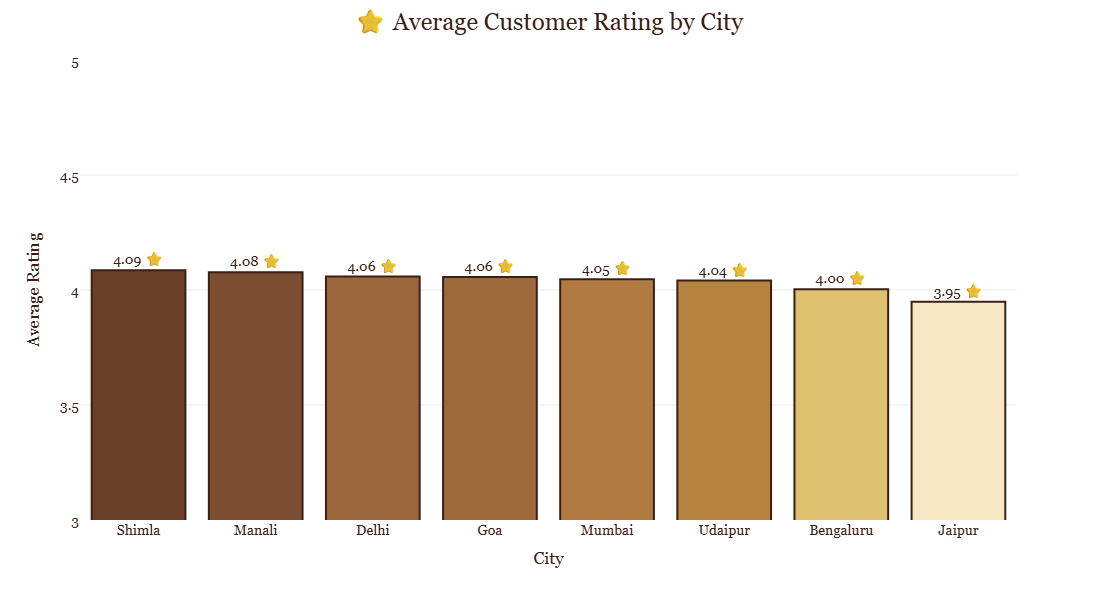

In [14]:
import plotly.express as px
import plotly.io as pio

pio.templates.default = "plotly_white"

avg_rating = (
    df.groupby("City", as_index=False)["Customer_Rating"]
      .mean()
      .sort_values(by="Customer_Rating", ascending=False)
)

fig = px.bar(

    avg_rating,

    x="City",

    y="Customer_Rating",

    text="Customer_Rating",

    color="Customer_Rating",

    color_continuous_scale=[
        "#F8E7C5",
        "#E8D8B8",
        "#D4AF37",
        "#A97142",
        "#6B3F2A"
    ]

)

fig.update_traces(

    texttemplate="%{text:.2f} ⭐",

    textposition="outside",

    marker_line_color="#3B1F14",

    marker_line_width=2,

    hovertemplate="<b>%{x}</b><br>Average Rating : %{y:.2f} ⭐<extra></extra>"

)

fig.update_layout(

    title=dict(

        text="⭐ Average Customer Rating by City",

        x=0.5,

        font=dict(size=24)

    ),

    height=600,

    width=800,

    plot_bgcolor="white",

    paper_bgcolor="white",

    coloraxis_showscale=False,

    font=dict(

        family="Georgia",

        size=14,

        color="#3B1F14"

    ),

    xaxis=dict(

        title="City",

        showgrid=False

    ),

    yaxis=dict(

        title="Average Rating",

        range=[3,5],

        gridcolor="rgba(0,0,0,0.08)"

    )

)

fig.show()

<div style="
background:#3B1F14;
padding:20px;
border-radius:18px;
border:3px solid #D4AF37;
text-align:center;
">

<h1 style="
color:#F8E7C5;
margin:0;
font-size:30px;
">

💰 Average Hotel Price by City

</h1>

</div>


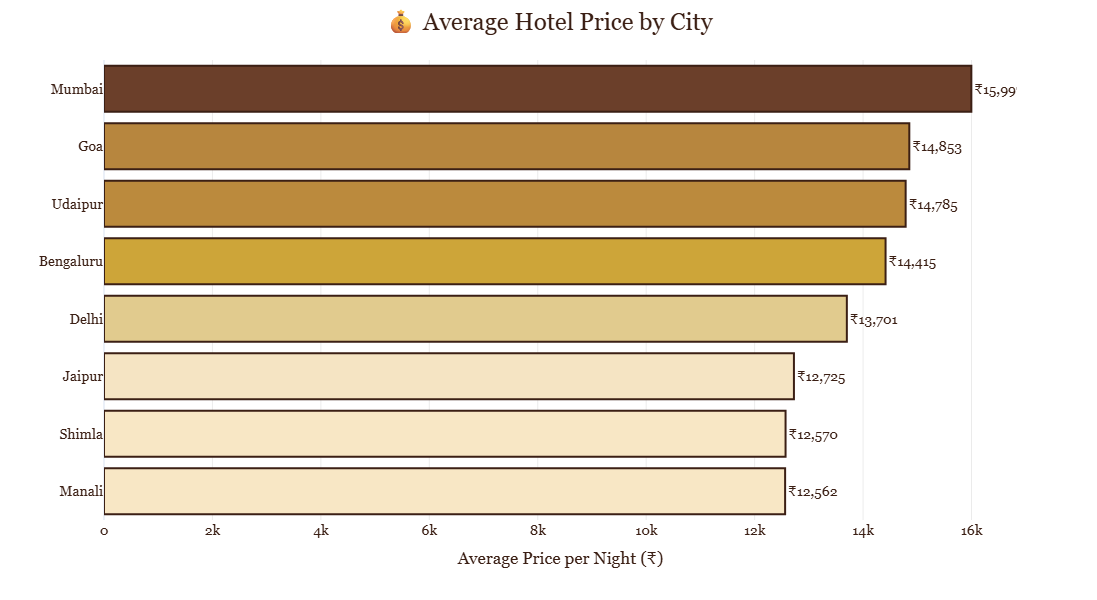

In [17]:
import plotly.express as px

# Average price by city
avg_price = (
    df.groupby("City", as_index=False)["Price_per_Night"]
      .mean()
      .sort_values(by="Price_per_Night", ascending=True)
)

fig = px.bar(
    avg_price,
    x="Price_per_Night",
    y="City",
    orientation="h",
    text="Price_per_Night",
    color="Price_per_Night",

    color_continuous_scale=[
        "#F8E7C5",
        "#E8D8B8",
        "#D4AF37",
        "#A97142",
        "#6B3F2A"
    ]
)

fig.update_traces(
    texttemplate="₹%{text:,.0f}",
    textposition="outside",
    marker_line_color="#3B1F14",
    marker_line_width=2,
    hovertemplate="<b>%{y}</b><br>Average Price: ₹%{x:,.0f}<extra></extra>"
)

fig.update_layout(

    title=dict(
        text="💰 Average Hotel Price by City",
        x=0.5,
        font=dict(size=24)
    ),

    height=600,
    width=800,

    plot_bgcolor="white",
    paper_bgcolor="white",

    coloraxis_showscale=False,

    font=dict(
        family="Georgia",
        size=14,
        color="#3B1F14"
    ),

    xaxis=dict(
        title="Average Price per Night (₹)",
        gridcolor="rgba(0,0,0,0.08)"
    ),

    yaxis=dict(
        title="",
        showgrid=False
    )
)

fig.show()

<div style="
background:#3B1F14;
padding:20px;
border-radius:18px;
border:3px solid #D4AF37;
text-align:center;
">

<h1 style="
color:#F8E7C5;
margin:0;
font-size:30px;
">

🍩 Hotel Type Distribution

</h1>

</div>


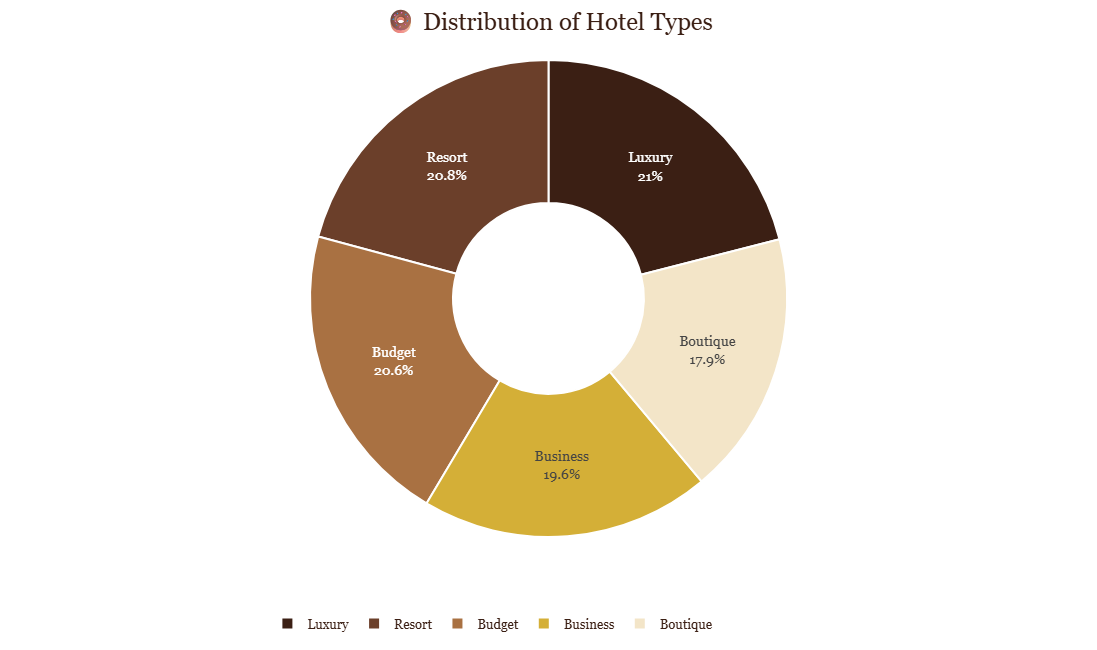

In [20]:
import plotly.express as px

hotel_type = (
    df["Hotel_Type"]
    .value_counts()
    .reset_index()
)

hotel_type.columns = ["Hotel Type", "Count"]

colors = [
    "#3B1F14",   # Dark Brown
    "#6B3F2A",   # Brown
    "#A97142",   # Light Brown
    "#D4AF37",   # Gold
    "#F3E5C8"    # Beige
]

fig = px.pie(
    hotel_type,
    names="Hotel Type",
    values="Count",
    hole=0.40,
    color="Hotel Type",
    color_discrete_sequence=colors
)

fig.update_traces(

    textposition="inside",

    textinfo="percent+label",

    textfont_size=14,

    marker=dict(
        line=dict(
            color="white",
            width=2
        )
    ),

    hovertemplate=
    "<b>%{label}</b><br>" +
    "Hotels : %{value}<br>" +
    "Percentage : %{percent}<extra></extra>"
)

fig.update_layout(

    title=dict(
        text="🍩 Distribution of Hotel Types",
        x=0.5,
        font=dict(size=24)
    ),

    height=650,
    width=900,

    paper_bgcolor="white",
    plot_bgcolor="white",

    legend=dict(
        orientation="h",
        y=-0.15,
        x=0.2,
        font=dict(size=13)
    ),

    font=dict(
        family="Georgia",
        size=14,
        color="#3B1F14"
    )
)

fig.show()

<div style="
background:#3B1F14;
padding:20px;
border-radius:18px;
border:3px solid #D4AF37;
text-align:center;
">

<h1 style="
color:#F8E7C5;
margin:0;
font-size:30px;
">

🏨 Top 10 Most Expensive Hotels

</h1>

</div>


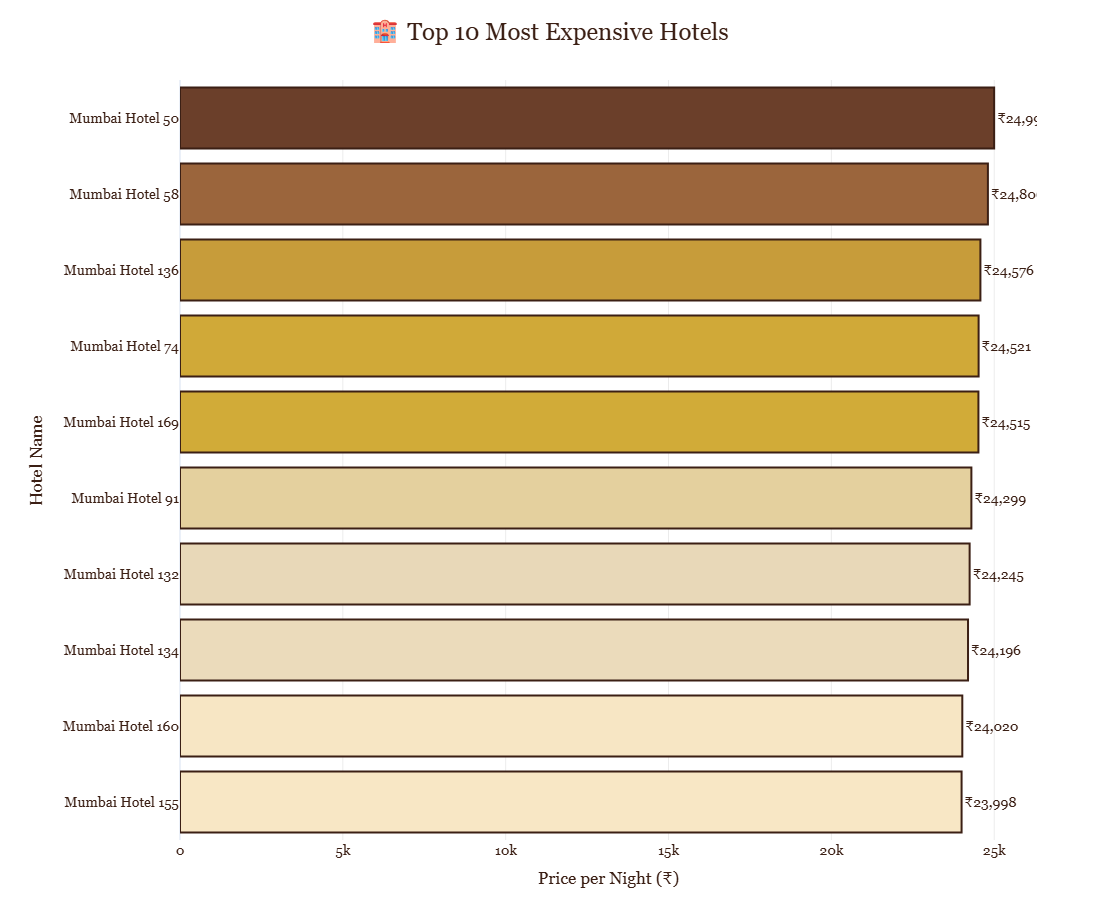

In [24]:
import plotly.express as px

# Top 10 Most Expensive Hotels
top_hotels = (
    df.sort_values("Price_per_Night", ascending=False)
      .head(10)
)

fig = px.bar(
    top_hotels,
    x="Price_per_Night",
    y="Hotel_Name",
    orientation="h",
    text="Price_per_Night",
    color="Price_per_Night",

    color_continuous_scale=[
        "#F8E7C5",
        "#E8D8B8",
        "#D4AF37",
        "#A97142",
        "#6B3F2A"
    ]
)

fig.update_traces(
    texttemplate="₹%{text:,.0f}",
    textposition="outside",
    marker_line_color="#3B1F14",
    marker_line_width=2,
    hovertemplate="<b>%{y}</b><br>Price per Night: ₹%{x:,.0f}<extra></extra>"
)

fig.update_layout(

    title=dict(
        text="🏨 Top 10 Most Expensive Hotels",
        x=0.5,
        font=dict(size=24)
    ),

    height=900,
    width=600,

    plot_bgcolor="white",
    paper_bgcolor="white",

    coloraxis_showscale=False,

    font=dict(
        family="Georgia",
        size=14,
        color="#3B1F14"
    ),

    xaxis=dict(
        title="Price per Night (₹)",
        gridcolor="rgba(0,0,0,0.08)"
    ),

    yaxis=dict(
        title="Hotel Name",
        categoryorder="total ascending",
        showgrid=False
    ),

    margin=dict(l=180, r=60, t=80, b=60)
)

fig.show()

<div style="
background:#3B1F14;
padding:20px;
border-radius:18px;
border:3px solid #D4AF37;
text-align:center;
">

<h1 style="
color:#F8E7C5;
margin:0;
font-size:30px;
">

📈 Hotel Price Distribution

</h1>

</div>


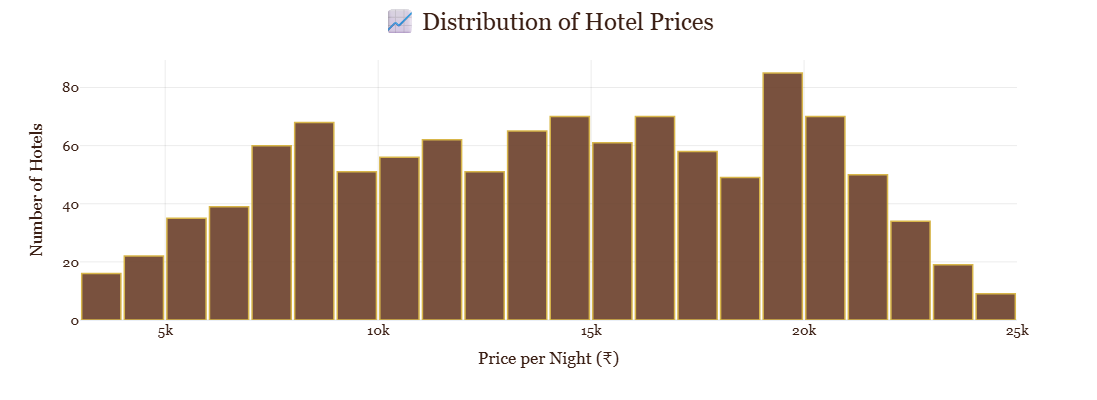

In [27]:
import plotly.express as px

fig = px.histogram(
    df,
    x="Price_per_Night",
    nbins=30,
    color_discrete_sequence=["#6B3F2A"],
    opacity=0.9
)

fig.update_traces(

    marker=dict(
        line=dict(
            color="#D4AF37",
            width=1.5
        )
    ),

    hovertemplate=
    "<b>Price Range</b><br>" +
    "₹%{x:,.0f}<br>" +
    "Hotels: %{y}<extra></extra>"
)

fig.update_layout(

    title=dict(
        text="📈 Distribution of Hotel Prices",
        x=0.5,
        font=dict(size=24)
    ),

    height=400,
    width=650,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Georgia",
        size=14,
        color="#3B1F14"
    ),

    xaxis=dict(
        title="Price per Night (₹)",
        gridcolor="rgba(0,0,0,0.08)"
    ),

    yaxis=dict(
        title="Number of Hotels",
        gridcolor="rgba(0,0,0,0.08)"
    ),

    bargap=0.08
)

fig.show()

<div style="
background:#3B1F14;
padding:20px;
border-radius:18px;
border:3px solid #D4AF37;
text-align:center;
">

<h1 style="
color:#F8E7C5;
margin:0;
font-size:30px;
">

🎯 Price vs Customer Rating Analysis

</h1>

</div>


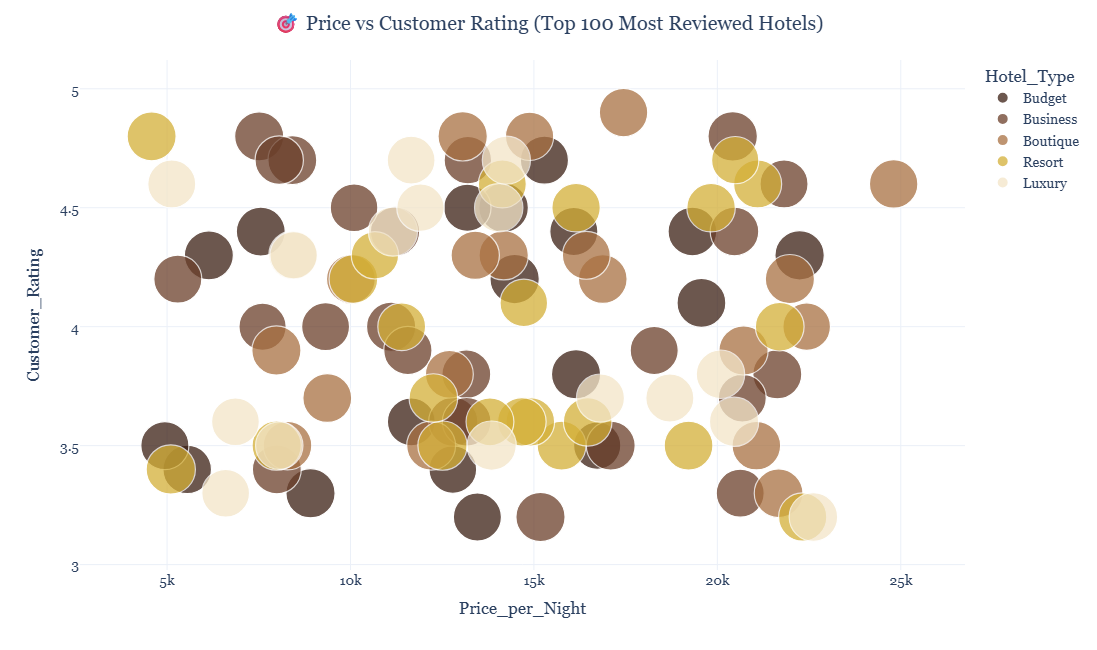

In [30]:
import plotly.express as px

# Top 100 hotels by reviews
bubble_df = (
    df.sort_values("Reviews", ascending=False)
      .head(100)
)

fig = px.scatter(
    bubble_df,
    x="Price_per_Night",
    y="Customer_Rating",
    size="Reviews",
    color="Hotel_Type",
    hover_name="Hotel_Name",
    hover_data=["City"],
    size_max=35,
    color_discrete_sequence=[
        "#3B1F14",
        "#6B3F2A",
        "#A97142",
        "#D4AF37",
        "#F3E5C8"
    ]
)

fig.update_traces(
    marker=dict(
        opacity=0.75,
        line=dict(color="white", width=1.2)
    )
)

fig.update_layout(
    title="🎯 Price vs Customer Rating (Top 100 Most Reviewed Hotels)",
    title_x=0.5,
    height=650,
    width=1000,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Georgia", size=14)
)

fig.show()

<div style="
background:#3B1F14;
padding:20px;
border-radius:18px;
border:3px solid #D4AF37;
text-align:center;
">

<h1 style="
color:#F8E7C5;
margin:0;
font-size:30px;
">

📦 Hotel Price Distribution by City

</h1>

</div>


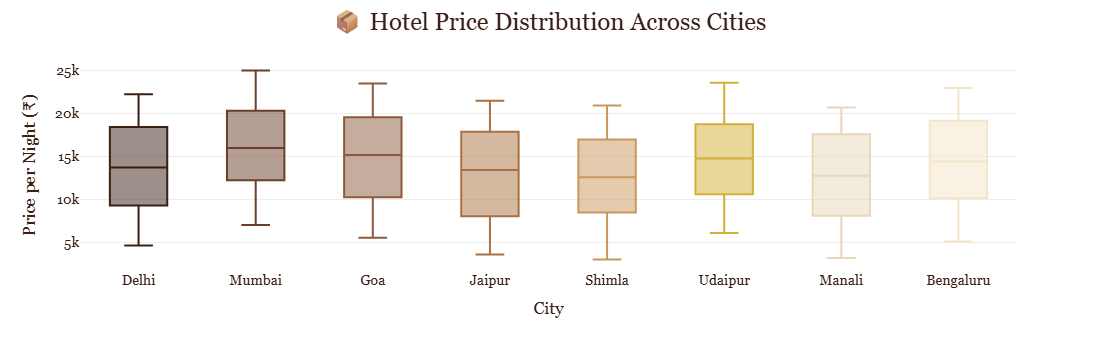

In [32]:
import plotly.express as px

fig = px.box(

    df,

    x="City",

    y="Price_per_Night",

    color="City",

    points="outliers",

    color_discrete_sequence=[
        "#3B1F14",
        "#6B3F2A",
        "#8C5A3C",
        "#A97142",
        "#C9975B",
        "#D4AF37",
        "#E8D8B8",
        "#F3E5C8"
    ]
)

fig.update_traces(

    marker=dict(
        size=5,
        opacity=0.7
    ),

    line=dict(width=2)

)

fig.update_layout(

    title=dict(

        text="📦 Hotel Price Distribution Across Cities",

        x=0.5,

        font=dict(size=24)

    ),

    height=350,

    width=700,

    plot_bgcolor="white",

    paper_bgcolor="white",

    showlegend=False,

    font=dict(

        family="Georgia",

        size=14,

        color="#3B1F14"

    ),

    xaxis=dict(

        title="City",

        showgrid=False

    ),

    yaxis=dict(

        title="Price per Night (₹)",

        gridcolor="rgba(0,0,0,0.08)"

    )

)

fig.show()

<div style="
background:#3B1F14;
padding:20px;
border-radius:18px;
border:3px solid #D4AF37;
text-align:center;
">

<h1 style="
color:#F8E7C5;
margin:0;
font-size:30px;
">

🔥 Correlation Heatmap

</h1>

</div>


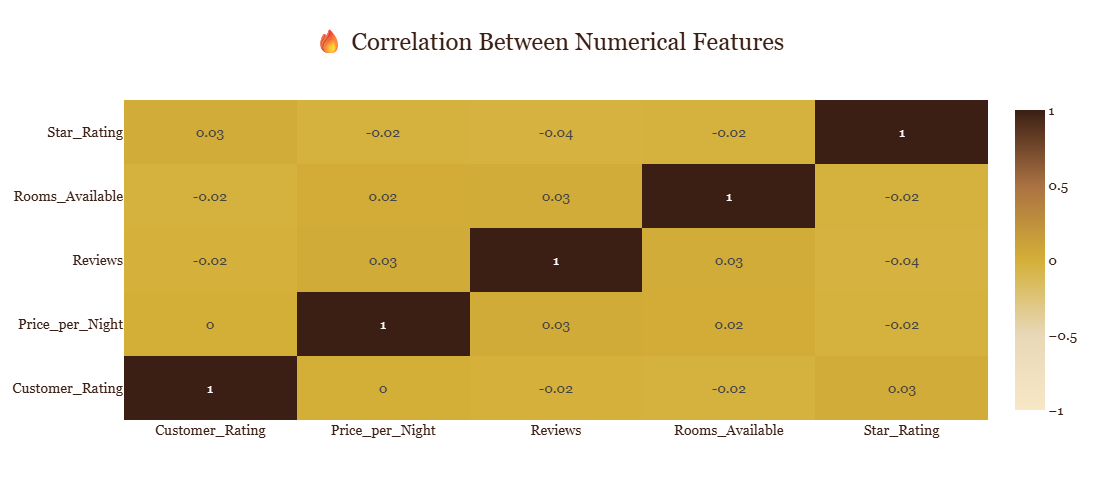

In [35]:
import plotly.graph_objects as go

# Select numerical columns
corr = df[
    [
        "Customer_Rating",
        "Price_per_Night",
        "Reviews",
        "Rooms_Available",
        "Star_Rating"
    ]
].corr()

fig = go.Figure(
    data=go.Heatmap(

        z=corr.values,

        x=corr.columns,

        y=corr.columns,

        text=corr.round(2).values,

        texttemplate="%{text}",

        colorscale=[
            [0.0, "#F8E7C5"],
            [0.25, "#E8D8B8"],
            [0.50, "#D4AF37"],
            [0.75, "#A97142"],
            [1.0, "#3B1F14"]
        ],

        zmin=-1,

        zmax=1,

        hovertemplate=
        "<b>%{x}</b> vs <b>%{y}</b><br>" +
        "Correlation: %{z:.2f}<extra></extra>"
    )
)

fig.update_layout(

    title=dict(

        text="🔥 Correlation Between Numerical Features",

        x=0.5,

        font=dict(size=24)

    ),

    height=500,

    width=650,

    plot_bgcolor="white",

    paper_bgcolor="white",

    font=dict(

        family="Georgia",

        size=14,

        color="#3B1F14"

    )

)

fig.show()

<div style="
background:#3B1F14;
padding:20px;
border-radius:18px;
border:3px solid #D4AF37;
text-align:center;
">

<h1 style="
color:#F8E7C5;
margin:0;
font-size:30px;
">

🌳 Hotel Distribution by City & Type

</h1>

</div>


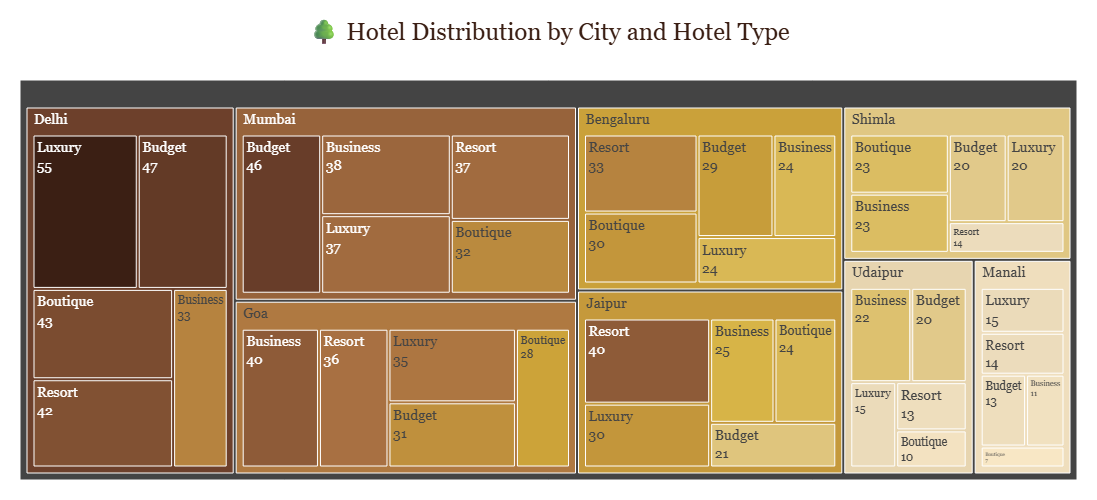

In [37]:
import plotly.express as px

treemap_df = (
    df.groupby(["City", "Hotel_Type"])
      .size()
      .reset_index(name="Hotels")
)

fig = px.treemap(
    treemap_df,
    path=["City", "Hotel_Type"],
    values="Hotels",
    color="Hotels",
    color_continuous_scale=[
        "#F8E7C5",
        "#E8D8B8",
        "#D4AF37",
        "#A97142",
        "#6B3F2A",
        "#3B1F14"
    ]
)

fig.update_traces(

    textinfo="label+value",

    hovertemplate=
    "<b>%{label}</b><br>" +
    "Hotels: %{value}<extra></extra>"
)

fig.update_layout(

    title=dict(

        text="🌳 Hotel Distribution by City and Hotel Type",

        x=0.5,

        font=dict(size=24)

    ),

    height=500,

    width=750,

    paper_bgcolor="white",

    plot_bgcolor="white",

    coloraxis_showscale=False,

    margin=dict(t=80, l=20, r=20, b=20),

    font=dict(

        family="Georgia",

        size=14,

        color="#3B1F14"

    )
)

fig.show()

<div style="
background:#3B1F14;
padding:20px;
border-radius:18px;
border:3px solid #D4AF37;
text-align:center;
">

<h1 style="
color:#F8E7C5;
margin:0;
font-size:30px;
">

🏨 Average Hotel Price by Hotel Type

</h1>

</div>


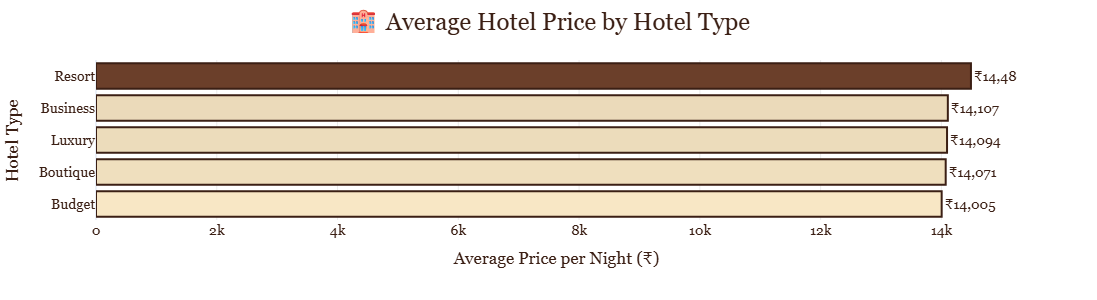

In [49]:
import plotly.express as px

avg_type = (
    df.groupby("Hotel_Type", as_index=False)["Price_per_Night"]
      .mean()
      .sort_values(by="Price_per_Night", ascending=True)
)

fig = px.bar(

    avg_type,

    x="Price_per_Night",

    y="Hotel_Type",

    orientation="h",

    text="Price_per_Night",

    color="Price_per_Night",

    color_continuous_scale=[
        "#F8E7C5",
        "#E8D8B8",
        "#D4AF37",
        "#A97142",
        "#6B3F2A"
    ]

)

fig.update_traces(

    texttemplate="₹%{text:,.0f}",

    textposition="outside",

    marker_line_color="#3B1F14",

    marker_line_width=2,

    hovertemplate=
    "<b>%{y}</b><br>" +
    "Average Price : ₹%{x:,.0f}<extra></extra>"

)

fig.update_layout(

    title=dict(

        text="🏨 Average Hotel Price by Hotel Type",

        x=0.5,

        font=dict(size=24)

    ),

    height=300,

    width=650,

    plot_bgcolor="white",

    paper_bgcolor="white",

    coloraxis_showscale=False,

    font=dict(

        family="Georgia",

        size=14,

        color="#3B1F14"

    ),

    xaxis=dict(

        title="Average Price per Night (₹)",

        gridcolor="rgba(0,0,0,0.08)"

    ),

    yaxis=dict(

        title="Hotel Type",

        showgrid=False

    )

)

fig.show()

In [43]:
df.columns

Index(['Hotel_ID', 'Hotel_Name', 'City', 'Location', 'Hotel_Type',
       'Star_Rating', 'Customer_Rating', 'Reviews', 'Price_per_Night',
       'Rooms_Available', 'Latitude', 'Longitude'],
      dtype='object')

<div style="
background:#3B1F14;
padding:20px;
border-radius:18px;
border:3px solid #D4AF37;
text-align:center;
">

<h1 style="
color:#F8E7C5;
margin:0;
font-size:30px;
">

🗺️ Hotel Locations Across India

</h1>

</div>

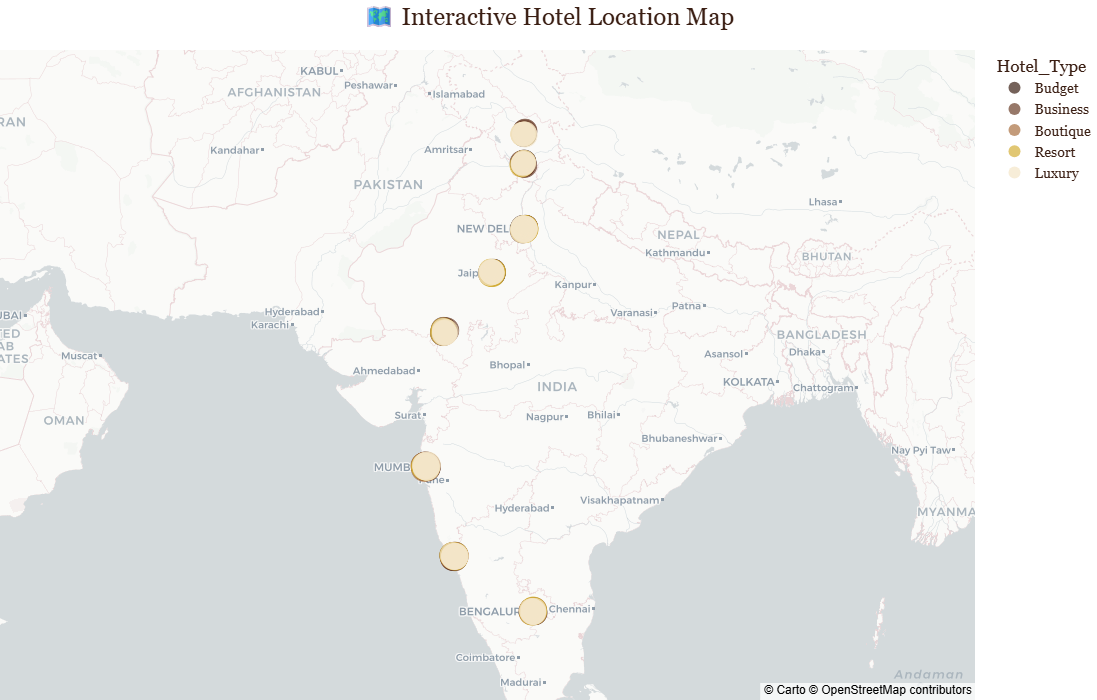

In [46]:
import plotly.express as px

fig = px.scatter_mapbox(

    df,

    lat="Latitude",

    lon="Longitude",

    hover_name="Hotel_Name",

    hover_data={
        "City": True,
        "Price_per_Night": True,
        "Customer_Rating": True
    },

    color="Hotel_Type",

    size="Price_per_Night",

    zoom=4,

    height=700,

    color_discrete_sequence=[
        "#3B1F14",
        "#6B3F2A",
        "#A97142",
        "#D4AF37",
        "#F3E5C8"
    ]
)

fig.update_layout(

    mapbox_style="carto-positron",

    margin=dict(l=0, r=0, t=50, b=0),

    title=dict(

        text="🗺️ Interactive Hotel Location Map",

        x=0.5,

        font=dict(size=24)

    ),

    font=dict(
        family="Georgia",
        size=14,
        color="#3B1F14"
    )
)

fig.show()

<div style="
background:#3B1F14;
padding:25px;
border-radius:20px;
border:3px solid #D4AF37;
box-shadow:0px 0px 15px rgba(212,175,55,0.3);
">

<h1 style="
text-align:center;
color:#F8E7C5;
font-size:32px;
margin-bottom:20px;
">

💼 Business Insights

</h1>

<div style="
color:#F3E5C8;
font-size:18px;
line-height:2;
">

<ul>

<li><b>Delhi</b> and <b>Mumbai</b> have the highest concentration of hotels, indicating strong demand in metropolitan markets.</li>

<li>Luxury hotels charge significantly higher prices, while Budget hotels attract price-sensitive customers.</li>

<li>Customer ratings remain consistently high across most cities, reflecting positive guest experiences.</li>

<li>Only a small percentage of hotels belong to the premium pricing segment, indicating a niche luxury market.</li>

<li>Tourist destinations such as <b>Goa</b> and <b>Manali</b> show strong hospitality performance with competitive customer ratings.</li>

<li>Price alone does not guarantee better customer ratings, suggesting that service quality plays an equally important role.</li>

<li>Hotel type and location are the two strongest factors influencing accommodation pricing.</li>

</ul>

</div>

</div>


<div style="
background:#3B1F14;
padding:25px;
border-radius:20px;
border:3px solid #D4AF37;
box-shadow:0px 0px 15px rgba(212,175,55,0.3);
">

<h1 style="
text-align:center;
color:#F8E7C5;
font-size:32px;
margin-bottom:20px;
">

📋 Project Conclusion

</h1>

<div style="
color:#F3E5C8;
font-size:18px;
line-height:2;
text-align:justify;
">

This project successfully explored hotel data collected from multiple Indian cities using Python, Pandas, and Plotly. Through exploratory data analysis and interactive visualizations, valuable insights were obtained regarding hotel pricing, customer ratings, hotel categories, reviews, and geographical distribution.

The analysis revealed that hotel prices are primarily influenced by city location and hotel type, while customer ratings remain consistently high across most destinations. These findings can support hospitality businesses in making informed decisions related to pricing strategies, service quality improvements, and market expansion.

Overall, this project demonstrates practical skills in data cleaning, exploratory data analysis, business intelligence, interactive dashboard development, and data storytelling, making it a valuable portfolio project for Data Analytics.

</div>

</div>



<div style="
background:#D4AF37;
padding:12px;
border-radius:12px;
text-align:center;
font-size:18px;
font-weight:bold;
color:#3B1F14;
">

⭐ Thank you for reviewing this Hotel Data Analytics Project ⭐

</div>
